In [2]:
from dataset_creation import build_dataset
from pathlib import Path
from sklearn.utils import shuffle

base_dir = Path().cwd()
train_dir = base_dir / "dataset" / "Train_preprocessed"
test_dir = base_dir / "dataset" / "Test_preprocessed"

X_train, y_train = build_dataset(train_dir)
X_test, y_test = build_dataset(test_dir)

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.00392157, 0.00392157,
        0.00392157],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(5600, 50176), dtype=float32)

In [3]:
import numpy as np

np.unique(y_train, return_counts=True)

(array([0, 1, 2, 3], dtype=int8), array([1400, 1400, 1400, 1400]))

In [4]:
# from sklearn.random_projection import SparseRandomProjection

# sparse_rnd_proj = SparseRandomProjection(random_state=42, n_components=20000)
# X_train_reduced = sparse_rnd_proj.fit_transform(X_train)
# X_train_reduced

In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def plot_cm(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'{model_name} Brain Tumor CLF Confusion Matrix')
    plt.show()

c:\Users\Adisa Teslim\OneDrive\Documents\Programming Journey\Machine Learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Classification Report
              precision    recall  f1-score   support

      glioma     0.7329    0.6175    0.6703       400
  meningioma     0.6711    0.7500    0.7084       400
    no_tumor     0.8581    0.9675    0.9095       400
   pituitary     0.8877    0.8100    0.8471       400

    accuracy                         0.7863      1600
   macro avg     0.7875    0.7863    0.7838      1600
weighted avg     0.7875    0.7863    0.7838      1600



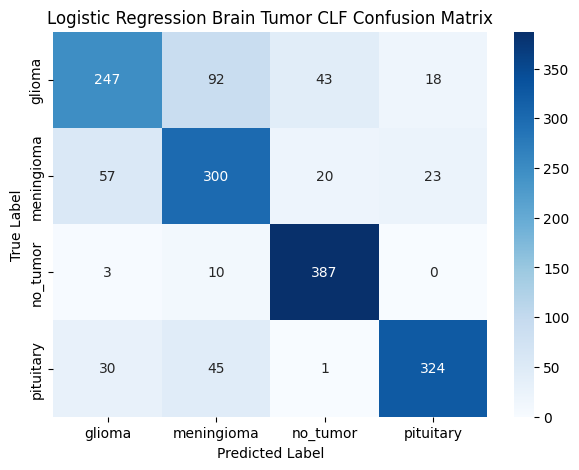

Macro-Averaged ROC-AUC: 0.9192


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

target_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
# X_test_reduced = sparse_rnd_proj.transform(X_test)

log_clf = LogisticRegression(max_iter=200)
log_clf.fit(X_train, y_train)
log_preds = log_clf.predict(X_test)

report_dict = classification_report(y_test, log_preds, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_test, log_preds, "Logistic Regression")

log_preds = log_clf.predict_proba(X_test)
auc = roc_auc_score(y_test, log_preds, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "logistic_regression_results.csv"

df_report.to_csv(output_dir)

Classification Report
              precision    recall  f1-score   support

      glioma     0.9353    0.6500    0.7670       400
  meningioma     0.7949    0.8625    0.8273       400
    no_tumor     0.8093    0.9975    0.8936       400
   pituitary     0.9494    0.9375    0.9434       400

    accuracy                         0.8619      1600
   macro avg     0.8722    0.8619    0.8578      1600
weighted avg     0.8722    0.8619    0.8578      1600



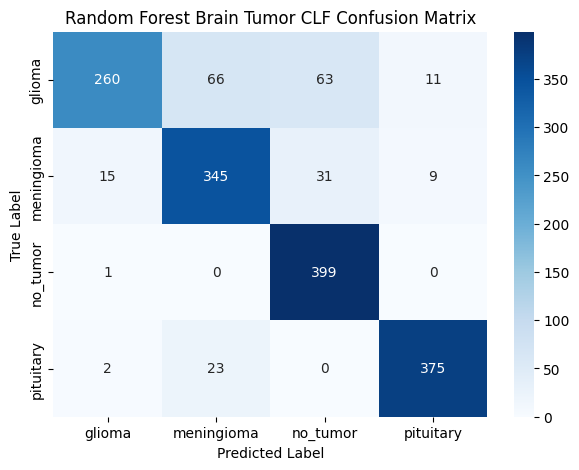

Macro-Averaged ROC-AUC: 0.9615


In [ ]:
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier()
forest_clf.fit(X_train, y_train)
forest_preds = forest_clf.predict(X_test)

report_dict = classification_report(y_test, forest_preds, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_test, forest_preds, "Random Forest")

forest_preds = forest_clf.predict_proba(X_test)
auc = roc_auc_score(y_test, forest_preds, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "random_forest_results.csv"

df_report.to_csv(output_dir)

In [ ]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier()
xgb_clf.fit(X_train, y_train)
xgb_preds = xgb_clf.predict(X_test)

report_dict = classification_report(y_test, xgb_preds, target_names=target_names, digits=4, output_dict=True)
print("Classification Report")
print(report_dict)

plot_cm(y_test, xgb_preds, "XGBoost")

xgb_preds = xgb_clf.predict_proba(X_test)
auc = roc_auc_score(y_test, xgb_preds, multi_class="ovr", average="macro")
print(f"Macro-Averaged ROC-AUC: {auc:.4f}")

report_dict['roc_auc'] = {'macro_avg_score': auc}
df_report = pd.DataFrame(report_dict).transpose()
output_dir = base_dir / "results" / "XGBoost_results.csv"

df_report.to_csv(output_dir)

XGBoostError: [16:26:53] C:\actions-runner\_work\xgboost\xgboost\src\common\io.h:362: bad_malloc: Failed to allocate 8331852048 bytes.